# PREDICTIVE ML MODEL TRAINING FOR HYDROLIC PRESS THROUGH CONDITION MONITORING OF HYDRAULIC SYSTEMS DATASET

### Set-up & Imports

In [1]:
# 0/ Setup & Imports
import warnings
warnings.filterwarnings('ignore')


import os
import glob
import joblib
import numpy as np
import pandas as pd
import xgboost as xgb
import matplotlib.pyplot as plt


from sklearn.feature_selection import mutual_info_regression as MIR
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import mean_absolute_error as MAE
from sklearn.metrics import mean_squared_error as MSE
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler
from scipy.stats import wasserstein_distance
from sklearn.metrics import r2_score
from scipy.stats import ks_2samp
from scipy.stats import kurtosis
from xgboost import XGBRegressor
from scipy.stats import skew
from tqdm import tqdm

# Reproducibility
np.random.seed(42)

# Display options for readable, aligned outputs
pd.set_option('display.width', 120)
pd.set_option('display.max_columns', None)
pd.set_option('display.precision', 3)

# Small helpers for tidy logs
def print_header(title: str):
    line = '=' * 70
    print(f"\n{line}\n{title}\n{line}")

def print_footer(title: str):
    line = '-' * 70
    print(f"\n{line}\n{title}\n{line}")

def print_kv(pairs):
    # pairs: list of (key, value)
    width = max(len(str(k)) for k, _ in pairs) if pairs else 0
    for k, v in pairs:
        print(f"{str(k).ljust(width)} : {v}")

def R_MSE(y_true, y_pred):
    return np.sqrt(MSE(y_true, y_pred))

def get_numeric_sensor_cols(df: pd.DataFrame, exclude_cols: set) -> list:
    cols = []
    for c in df.columns:
        if c in exclude_cols:
            continue
        if pd.api.types.is_numeric_dtype(df[c]):
            cols.append(c)
    return cols

# store results for comparison of trained models
results_dict = {}

# data directory
main_path = os.path.basename(os.getcwd())
if main_path != "hydraulic_press data":
    data_dir = "hydraulic_press data"  
    os.chdir(data_dir)
    

print_footer("SETUP AND IMPORTS COMPLETE")


----------------------------------------------------------------------
SETUP AND IMPORTS COMPLETE
----------------------------------------------------------------------


## 1) Load Profile.txt & Compute RUL

In [2]:
# 1/ LOAD PROFILE.TXT & COMPUTE RUL (DEGRADATION LOGIC)

print_header("1/ LOAD PROFILE.TXT & COMPUTE RUL ")

# function def
def compute_rul(profile_df, max_rul_cap=150):
    """
    Compute Remaining Useful Life (RUL) for hydraulic press cycles.
    RUL decreases until a failure condition occurs, then resets to max.
    """
    num_cycles = len(profile_df)
    rul = np.zeros(num_cycles, dtype=int)
    current_rul = max_rul_cap

    for i in range(num_cycles - 1, -1, -1):
        cooler = profile_df.loc[i, 'cooler']
        valve = profile_df.loc[i, 'valve']
        pump = profile_df.loc[i, 'pump']
        acc = profile_df.loc[i, 'accumulator']

        # failure logic (as defined by UCI dataset rules)
        if (cooler == 3) or (valve == 73) or (pump >= 3) or (acc == 90):
            current_rul = 0
        else:
            current_rul = min(current_rul + 1, max_rul_cap)

        rul[i] = current_rul

    return rul


# RUL calculation 
profile_path = "profile.txt"
profile = pd.read_csv(
                        profile_path,
                        sep='\t', 
                        header=None,
                        names=['cooler', 'valve', 'pump', 'accumulator', 'stable']
                    )

num_cycles = len(profile)
rul = compute_rul(profile, max_rul_cap=150)

# validation & summary
print_kv([
            ("Total cycles", num_cycles),
            ("RUL min", rul.min()),
            ("RUL max", rul.max()),
            ("Mean RUL", f"{rul.mean():.2f}")
        ])

print_footer("RUL COMPUTATION COMPLETE")



1/ LOAD PROFILE.TXT & COMPUTE RUL 
Total cycles : 2205
RUL min      : 0
RUL max      : 41
Mean RUL     : 4.74

----------------------------------------------------------------------
RUL COMPUTATION COMPLETE
----------------------------------------------------------------------


## 2) Sensor Files & Sampling Info

In [3]:
# 2/ Define Sensor Files & Sampling Info (CORRECTED FOR UCI STRUCTURE)

print_header("2/ DEFINE SENSOR FILES & SAMPLING INFO (ROWS=CYCLES, COLUMNS=SAMPLES)")

# Full list of 17 sensor files
sensor_files = [
                'PS1.txt', 'PS2.txt', 'PS3.txt', 'PS4.txt', 'PS5.txt', 'PS6.txt',     # 100 Hz
                'EPS1.txt',                                                           # 100 Hz
                'FS1.txt', 'FS2.txt',                                                 # 10 Hz
                'TS1.txt', 'TS2.txt', 'TS3.txt', 'TS4.txt',                           # 1 Hz
                'VS1.txt',                                                            # 1 Hz
                'CE.txt',                                                             # 1 Hz (virtual)
                'CP.txt',                                                             # 1 Hz (virtual)
                'SE.txt'                                                              # 1 Hz (virtual)
            ]

# Sampling rates & expected SAMPLES PER CYCLE (columns in file)
sensor_info = {
                'PS1.txt': (100, 6000, 'Pressure bar'),
                'PS2.txt': (100, 6000, 'Pressure bar'),
                'PS3.txt': (100, 6000, 'Pressure bar'),
                'PS4.txt': (100, 6000, 'Pressure bar'),
                'PS5.txt': (100, 6000, 'Pressure bar'),
                'PS6.txt': (100, 6000, 'Pressure bar'),
                'EPS1.txt': (100, 6000, 'Motor power W'),
                'FS1.txt': (10, 600, 'Volume flow l/min'),
                'FS2.txt': (10, 600, 'Volume flow l/min'),
                'TS1.txt': (1, 60, 'Temperature °C'),
                'TS2.txt': (1, 60, 'Temperature °C'),
                'TS3.txt': (1, 60, 'Temperature °C'),
                'TS4.txt': (1, 60, 'Temperature °C'),
                'VS1.txt': (1, 60, 'Vibration mm/s'),
                'CE.txt': (1, 60, 'Cooling efficiency % (virtual)'),
                'CP.txt': (1, 60, 'Cooling power kW (virtual)'),
                'SE.txt': (1, 60, 'Efficiency factor % (virtual)')
            }

# Print summary
print_kv([
            ("Total sensors", len(sensor_files)),
            ("100 Hz (6000 samples)", 7),
            ("10 Hz (600 samples)", 2),
            ("1 Hz (60 samples)", 8),
            ("Cycles (rows per file)", num_cycles),
            ("Cycle duration", "60 seconds")
        ])

# Table view
info_list = []
for f in sensor_files:
    rate, samples, desc = sensor_info[f]
    info_list.append((f, rate, samples, desc))

print("\nSensor Details:")
print(pd.DataFrame(info_list, columns=['File', 'Rate (Hz)', 'Samples/Cycle (columns)', 'Description'])
      .to_string(index=False))

# Pre-load all sensor DataFrames + validate shape
sensor_dfs = {}  # cache for later feature extraction
missing_files = []
shape_mismatches = []

for f in sensor_files:
    if not os.path.exists(f):
        missing_files.append(f)
    else:
        df_temp = pd.read_csv(f, sep='\t', header=None)
        actual_shape = df_temp.shape
        expected_samples = sensor_info[f][1]
        expected_shape = (num_cycles, expected_samples)
        if actual_shape != expected_shape:
            shape_mismatches.append((f, actual_shape, expected_shape))
        else:
            sensor_dfs[f] = df_temp  # cache if correct

print_kv([
            ("Missing files", missing_files if missing_files else "None"),
            ("Shape mismatches", shape_mismatches if shape_mismatches else "None")
        ])

assert len(missing_files) == 0, "Some sensor files missing!"
assert len(shape_mismatches) == 0, "Some files have wrong shape! (rows must be 2205, columns = samples)"

print(f"All {len(sensor_dfs)} sensor files loaded and validated successfully")

print_footer("SENSOR INFO COMPLETE")


2/ DEFINE SENSOR FILES & SAMPLING INFO (ROWS=CYCLES, COLUMNS=SAMPLES)
Total sensors          : 17
100 Hz (6000 samples)  : 7
10 Hz (600 samples)    : 2
1 Hz (60 samples)      : 8
Cycles (rows per file) : 2205
Cycle duration         : 60 seconds

Sensor Details:
    File  Rate (Hz)  Samples/Cycle (columns)                    Description
 PS1.txt        100                     6000                   Pressure bar
 PS2.txt        100                     6000                   Pressure bar
 PS3.txt        100                     6000                   Pressure bar
 PS4.txt        100                     6000                   Pressure bar
 PS5.txt        100                     6000                   Pressure bar
 PS6.txt        100                     6000                   Pressure bar
EPS1.txt        100                     6000                  Motor power W
 FS1.txt         10                      600              Volume flow l/min
 FS2.txt         10                      600         

## 3) Feature Extraction

In [4]:
# 3/ Feature Extraction 

print_header("3/ FEATURE EXTRACTION")

# Function definition
def extract_features_with_trend(arr_list, window_size=5):
    """
    Extract statistical and temporal trend features.
    Each arr in arr_list represents one cycle for a single sensor.
    """
    feats_all = []
    for i in range(len(arr_list)):
        arr = np.asarray(arr_list[i], dtype=np.float64).flatten()
        mean_ = np.mean(arr)
        std_ = np.std(arr, ddof=0)
        min_ = np.min(arr)
        max_ = np.max(arr)
        rms_ = np.sqrt(np.mean(arr ** 2))
        skew_ = skew(arr)
        kurt_ = kurtosis(arr)
        ptp_ = np.ptp(arr)

        # temporal trend (difference from rolling mean of previous N cycles)
        if i >= window_size:
            prev_vals = [np.mean(arr_list[j]) for j in range(i - window_size, i)]
            trend = mean_ - np.mean(prev_vals)
        else:
            trend = 0.0

        feats_all.append([mean_, std_, min_, max_, rms_, skew_, kurt_, ptp_, trend])
    return np.array(feats_all)

# Test application on fake data
print("Testing function on sample data...")

# Fake cycle data for different sampling rates
fake_100hz = np.sin(np.linspace(0, 10*np.pi, 6000)) + np.random.normal(0, 0.1, 6000)
fake_10hz  = np.random.uniform(50, 100, 600)
fake_1hz   = np.linspace(20, 80, 60) + np.random.normal(0, 2, 60)

feat_100 = extract_features_with_trend(fake_100hz)
feat_10  = extract_features_with_trend(fake_10hz)
feat_1   = extract_features_with_trend(fake_1hz)

# Validation prints
print_kv([
            ("100 Hz fake features", np.round(feat_100, 4)),
            ("10 Hz fake features", np.round(feat_10, 4)),
            ("1 Hz fake features", np.round(feat_1, 4))
        ])

# Quick real test on first cycle of PS1 (100 Hz)
ps1_first_cycle = sensor_dfs['PS1.txt'].iloc[0, :].values
real_feat = extract_features_with_trend([ps1_first_cycle])

print_kv([
            ("Real PS1 cycle 0 mean", f"{real_feat[0][0]:.4f}"),
            ("Real PS1 cycle 0 std", f"{real_feat[0][1]:.4f}"),
            ("Real PS1 cycle 0 rms", f"{real_feat[0][4]:.4f}")
        ])

# Validation
assert extract_features_with_trend([fake_100hz]).shape == (1, 9), "Feature count must be 9!"
assert not np.any(np.isnan(fake_100hz)), "NaN in real features!"


ps1_data = sensor_dfs['PS1.txt']
arr_list = [ps1_data.iloc[i, :].values for i in range(10)]
feat_sample = extract_features_with_trend(arr_list, window_size=3)
print(f"Sample feature shape (10 cycles, 9 features): {feat_sample.shape}")
print("Feature extraction function ready and validated")
print("Total features per cycle per sensor: 9")
print(f"Total features per cycle: {len(sensor_files) * 9} (will add RUL column later)")

print_footer("FEATURE EXTRACTION COMPLETE")


3/ FEATURE EXTRACTION
Testing function on sample data...
100 Hz fake features : [[ 0.0497  0.      0.0497 ...     nan  0.      0.    ]
 [-0.0086  0.     -0.0086 ...     nan  0.      0.    ]
 [ 0.0752  0.      0.0752 ...     nan  0.      0.    ]
 ...
 [-0.1322  0.     -0.1322 ...     nan  0.     -0.1402]
 [ 0.0416  0.      0.0416 ...     nan  0.      0.0327]
 [-0.117   0.     -0.117  ...     nan  0.     -0.1301]]
10 Hz fake features  : [[ 66.8225   0.      66.8225 ...      nan   0.       0.    ]
 [ 60.5604   0.      60.5604 ...      nan   0.       0.    ]
 [ 65.6591   0.      65.6591 ...      nan   0.       0.    ]
 ...
 [ 62.7544   0.      62.7544 ...      nan   0.     -13.0153]
 [ 56.3517   0.      56.3517 ...      nan   0.     -20.056 ]
 [ 52.9268   0.      52.9268 ...      nan   0.     -20.6771]]
1 Hz fake features   : [[18.3006  0.     18.3006 18.3006 18.3006     nan     nan  0.      0.    ]
 [20.051   0.     20.051  20.051  20.051      nan     nan  0.      0.    ]
 [23.0953  0.  

## 4) Extract Features

In [5]:
# 4/ Extract Features Loop 

print_header("4/ EXTRACT FEATURES FOR ALL CYCLES (CACHE ENABLED)")


# Cache file
cache_file = "hydraulic_features_rul.csv"

if os.path.exists(cache_file):
    print(f"Cache found: {cache_file}")
    print("Loading features from cache...")
    features_df = pd.read_csv(cache_file)
    features_df['RUL'] = rul
    print_kv([
                ("Loaded shape", features_df.shape),
                ("Sample columns", features_df.columns[:10].tolist())
            ])
else:
    print("No cache found. Starting feature extraction...")
    
    # List to hold all cycle features
    all_features = []
    
    # Progress bar
    for cycle_idx in tqdm(range(num_cycles), desc="Extracting features", unit="cycle"):
        cycle_feats = []
        
        # Extract from each sensor (use pre-loaded sensor_dfs)
        for sensor_file in sensor_files:
            arr_list = [sensor_dfs[sensor_file].iloc[j, :].values 
                        for j in range(max(0, cycle_idx - 5), cycle_idx + 1)]
            feats = extract_features_with_trend(arr_list, window_size=5)[-1]
            cycle_feats.extend(feats)
        
        all_features.append(cycle_feats)

    # Feature names (17 sensors x 9 stats)
    stat_names = ['mean', 'std', 'min', 'max', 'rms', 'skew', 'kurt', 'ptp', 'trend']
    feature_names = [f"{sensor[:-4]}_{stat}" for sensor in sensor_files for stat in stat_names]
    
    # Create DataFrame
    features_df = pd.DataFrame(all_features, columns=feature_names)
    features_df.fillna(0, inplace=True)  # handle any NaNs just in case
    # Add RUL column
    features_df['RUL'] = rul
    print("RUL column added")

    print_kv([
                ("Final feature count", features_df.shape[1] - 1),
                ("Rows (cycles)", features_df.shape[0]),
                ("Memory (MB)", f"{features_df.memory_usage(deep=True).sum() / 1e6:.2f}")
            ])
        

    # Save cache
    features_df.to_csv(cache_file, index=False)
    print(f"Features saved to cache: {cache_file} ({os.path.getsize(cache_file)/1e6:.2f} MB)")

# Validation
expected_feature_count = len(sensor_files) * 9 + 1

assert features_df.shape[0] == num_cycles, f"Cycle count mismatch! Expected {num_cycles}, got {features_df.shape[0]}"

assert features_df.shape[1] == expected_feature_count, f"Feature count mismatch! Expected {expected_feature_count} columns (including RUL), got {features_df.shape[1]}"

assert 'RUL' in features_df.columns, "RUL column missing!"

assert not features_df.isnull().any().any(), "NaN values detected in features!"


# Sample output
print("\nFirst 3 rows sample:")
print(features_df.head(3).to_string(index=False))

print_kv([
            ("Final DF shape", features_df.shape),
            ("RUL min/max", f"{features_df['RUL'].min()} / {features_df['RUL'].max()}"),
            ("Memory usage", f"{features_df.memory_usage(deep=True).sum()/1e6:.2f} MB")
        ])

print("Feature extraction complete and cached for future runs")

print_footer("FEATURE EXTRACTION COMPLETE")


4/ EXTRACT FEATURES FOR ALL CYCLES (CACHE ENABLED)
No cache found. Starting feature extraction...


Extracting features: 100%|██████████| 2205/2205 [09:09<00:00,  4.01cycle/s]


RUL column added
Final feature count : 153
Rows (cycles)       : 2205
Memory (MB)         : 2.72
Features saved to cache: hydraulic_features_rul.csv (5.24 MB)

First 3 rows sample:
 PS1_mean  PS1_std  PS1_min  PS1_max  PS1_rms  PS1_skew  PS1_kurt  PS1_ptp  PS1_trend  PS2_mean  PS2_std  PS2_min  PS2_max  PS2_rms  PS2_skew  PS2_kurt  PS2_ptp  PS2_trend  PS3_mean  PS3_std  PS3_min  PS3_max  PS3_rms  PS3_skew  PS3_kurt  PS3_ptp  PS3_trend  PS4_mean  PS4_std  PS4_min  PS4_max  PS4_rms  PS4_skew  PS4_kurt  PS4_ptp  PS4_trend  PS5_mean  PS5_std  PS5_min  PS5_max  PS5_rms  PS5_skew  PS5_kurt  PS5_ptp  PS5_trend  PS6_mean  PS6_std  PS6_min  PS6_max  PS6_rms  PS6_skew  PS6_kurt  PS6_ptp  PS6_trend  EPS1_mean  EPS1_std  EPS1_min  EPS1_max  EPS1_rms  EPS1_skew  EPS1_kurt  EPS1_ptp  EPS1_trend  FS1_mean  FS1_std  FS1_min  FS1_max  FS1_rms  FS1_skew  FS1_kurt  FS1_ptp  FS1_trend  FS2_mean  FS2_std  FS2_min  FS2_max  FS2_rms   FS2_skew  FS2_kurt  FS2_ptp  FS2_trend  TS1_mean  TS1_std  TS1_min  TS1_ma

## 5) Splitting and Scaling for Training

In [ ]:
# 5/ TRAIN-TEST SPLIT & SCALING (STRATIFIED BY RUL INTERVALS)

print_header("5/ TRAIN-TEST SPLIT & SCALING")

#function definitions
def stratified_split(X, y, n_bins=5, test_size=0.2, random_state=42):
    """
    Perform stratified train-test split based on binned RUL values.
    """

    bins = pd.cut(y, bins=n_bins, labels=False)
    splitter = StratifiedShuffleSplit(n_splits=1, test_size=test_size, random_state=random_state)
    for train_idx, test_idx in splitter.split(X, bins):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    return X_train, X_test, y_train, y_test


# apply
cache_file = "hydraulic_features_rul.csv"
if 'features_df' not in globals():
    features_df = pd.read_csv(cache_file)
    print("Features loaded from cache.")

y = features_df['RUL']
X = features_df.drop('RUL', axis=1)

X_train, X_test, y_train, y_test = stratified_split(X, y, n_bins=5, test_size=0.2)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

joblib.dump(scaler, "hydraulic_scaler.pkl")

# validation
print_kv([
            ("Train samples", len(y_train)),
            ("Test samples", len(y_test)),
            ("Train RUL mean", f"{y_train.mean():.2f}"),
            ("Test RUL mean", f"{y_test.mean():.2f}"),
            ("Scaler file", "hydraulic_scaler.pkl")
        ])

print_footer("SPLIT & SCALING COMPLETE")



5/ TRAIN-TEST SPLIT & SCALING
Train samples  : 1764
Test samples   : 441
Train RUL mean : 4.71
Test RUL mean  : 4.89
Scaler file    : hydraulic_scaler.pkl

----------------------------------------------------------------------
SPLIT & SCALING COMPLETE
----------------------------------------------------------------------


## 6) XGBoost Training

In [ ]:
# 6/ XGBOOST MODEL TRAINING

print_header("6/ XGBOOST MODEL TRAINING")

# main model setup
model = xgb.XGBRegressor(
                            n_estimators=600,
                            learning_rate=0.03,
                            max_depth=6,
                            min_child_weight=2,
                            subsample=0.8,
                            colsample_bytree=0.8,
                            reg_lambda=1.0,
                            reg_alpha=0.1,
                            random_state=42,
                            tree_method='hist',
                            eval_metric='mae',
                            early_stopping_rounds=50,
                            n_jobs=-1
                        )

# train-validation split
val_split_idx = int(0.9 * len(X_train_scaled))
X_train_final = X_train_scaled[:val_split_idx]
y_train_final = y_train.iloc[:val_split_idx]
X_val = X_train_scaled[val_split_idx:]
y_val = y_train.iloc[val_split_idx:]

# training
print("Training started...")
model.fit(
            X_train_final,
            y_train_final,
            eval_set=[(X_val, y_val)],
            verbose=50,
        )

# evaluation on test data
y_pred = model.predict(X_test_scaled)

mae = MAE(y_test, y_pred)
rmse = R_MSE(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print_kv([
            ("Test MAE", f"{mae:.2f} cycles"),
            ("Test RMSE", f"{rmse:.2f} cycles"),
            ("Test R2", f"{r2:.4f}"),
            ("Target", "MAE < 10 & R2 > 0")
        ])

# save model
model.save_model("hydraulic_press_rul_xgb.json")
print("Model saved: hydraulic_press_rul_xgb.json")

# validation
assert mae < 20, "Model too inaccurate!"
print("XGBoost training completed successfully.")

print_footer("XGBOOST TRAINING COMPLETE")



6/ XGBOOST MODEL TRAINING
Training started...
[0]	validation_0-mae:7.38498
[50]	validation_0-mae:2.56682
[100]	validation_0-mae:1.43431
[150]	validation_0-mae:1.19300
[200]	validation_0-mae:1.13991
[250]	validation_0-mae:1.12087
[300]	validation_0-mae:1.10863
[350]	validation_0-mae:1.10288
[400]	validation_0-mae:1.09985
[450]	validation_0-mae:1.09806
[500]	validation_0-mae:1.09872
[513]	validation_0-mae:1.09883
Test MAE  : 0.91 cycles
Test RMSE : 1.91 cycles
Test R2   : 0.9578
Target    : MAE < 10 & R2 > 0
Model saved: hydraulic_press_rul_xgb.json
XGBoost training completed successfully.

----------------------------------------------------------------------
XGBOOST TRAINING COMPLETE
----------------------------------------------------------------------


## 7) Degradation Test


7/ REAL DEGRADATION TEST
Real test samples : 441
RUL range         : 0 -> 41
MAE               : 0.91 cycles
RMSE              : 1.91 cycles
R2                : 0.9578
Target            : MAE < 10 & R2 > 0


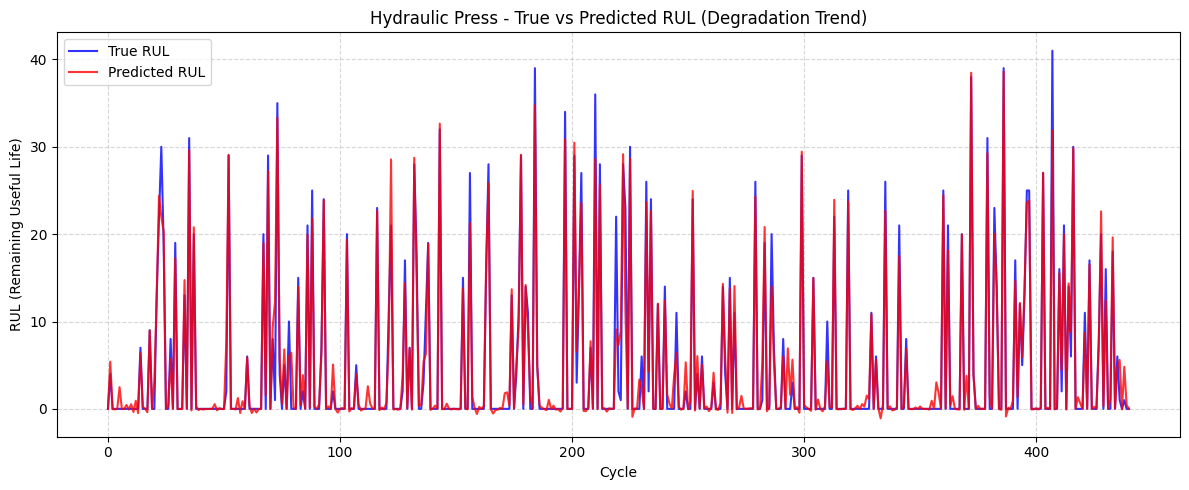


----------------------------------------------------------------------
TEST COMPLETED
----------------------------------------------------------------------


In [8]:
# 7/ REAL DEGRADATION TEST (VISUAL & PERFORMANCE VALIDATION)

print_header("7/ REAL DEGRADATION TEST")

# Evaluation
X_real_test = X_test_scaled
y_real_test = y_test
y_pred_real = model.predict(X_real_test)

mae_real = MAE(y_real_test, y_pred_real)
rmse_real = R_MSE(y_real_test, y_pred_real)
r2_real = r2_score(y_real_test, y_pred_real)

print_kv([
            ("Real test samples", len(y_real_test)),
            ("RUL range", f"{y_real_test.min()} -> {y_real_test.max()}"),
            ("MAE", f"{mae_real:.2f} cycles"),
            ("RMSE", f"{rmse_real:.2f} cycles"),
            ("R2", f"{r2_real:.4f}"),
            ("Target", "MAE < 10 & R2 > 0")
        ])

# Visualization

plt.figure(figsize=(12, 5))
plt.plot(y_real_test.values, label="True RUL", color='blue', alpha=0.8)
plt.plot(y_pred_real, label="Predicted RUL", color='red', alpha=0.8)
plt.title("Hydraulic Press - True vs Predicted RUL (Degradation Trend)")
plt.xlabel("Cycle")
plt.ylabel("RUL (Remaining Useful Life)")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig("hydraulic_press_rul_trend.png", dpi=300)
plt.show()

print_footer("TEST COMPLETED")


## 8) Drift Test

In [9]:
# 8/ MODEL DRIFT VALIDATION 

print_header("8/ MODEL DRIFT VALIDATION")

# helper functions
def find_file_recursive(patterns, root="."):
    """Return first match for any pattern (recursive)."""
    for pat in patterns:
        matches = glob.glob(os.path.join(root, "**", pat), recursive=True)
        if matches:
            return matches[0]
    return None

def load_artifacts(feature_candidates=None, scaler_candidates=None, model_candidates=None, root="."):
    """Locate and load feature CSV, scaler (.pkl) and model (.json)."""
    if feature_candidates is None:
        feature_candidates = ["hydraulic_features_rul_trend.csv", "hydraulic_features_rul.csv", "*features*.csv"]
    if scaler_candidates is None:
        scaler_candidates = ["hydraulic_scaler.pkl", "*.pkl"]
    if model_candidates is None:
        model_candidates = ["hydraulic_press_rul_xgb_optimized.json", "hydraulic_press_rul_xgb.json", "*.json"]
    feat = find_file_recursive(feature_candidates, root=root)
    if feat is None:
        raise FileNotFoundError("Feature CSV not found. Run previous cells first.")
    scaler = find_file_recursive(scaler_candidates, root=root)
    if scaler is None:
        raise FileNotFoundError("Scaler .pkl not found. Run previous cells first.")
    model_file = find_file_recursive(model_candidates, root=root)
    if model_file is None:
        raise FileNotFoundError("Model .json not found. Run previous cells first.")

    df = pd.read_csv(feat)
    scaler_obj = joblib.load(scaler)
    model = xgb.XGBRegressor()
    model.load_model(model_file)
    return df, scaler_obj, model, feat, scaler, model_file

def ks_wasserstein_report(X_ref, X_target, feature_names):
    """Return DataFrame with KS stat/p-value and Wasserstein distance per feature."""
    rows = []
    for i, f in enumerate(feature_names):
        a = X_ref[:, i]
        b = X_target[:, i]
        ks_stat, ks_p = ks_2samp(a, b)
        w = wasserstein_distance(a, b)
        rows.append((f, float(ks_stat), float(ks_p), float(w), float(a.mean()), float(b.mean())))
    cols = ["feature", "ks_stat", "ks_p", "wasserstein", "ref_mean", "target_mean"]
    return pd.DataFrame(rows, columns=cols)

def performance_by_rul_bins(y_true, y_pred, n_bins=6):
    """Return MAE per RUL quantile bin to check heteroscedasticity."""
    bins = pd.qcut(y_true, q=n_bins, duplicates='drop')
    res = []
    for grp, idxs in bins.groupby(bins).groups.items():
        idx = list(idxs)
        mae = MAE(y_true.iloc[idx], y_pred[idx])
        res.append((str(grp), len(idx), float(mae)))
    return pd.DataFrame(res, columns=["rul_bin", "count", "mae"])

# load
features_df, scaler, model, feat_path, scaler_path, model_path = load_artifacts(root=".")
print("Loaded:", feat_path, scaler_path, model_path)

# prepare matrices
assert 'RUL' in features_df.columns, "RUL column missing in feature CSV"
feature_cols = [c for c in features_df.columns if c != 'RUL']
X = features_df[feature_cols].copy()
y = features_df['RUL'].copy()

# create two splits:
    # time-based (last 20% cycles)
    # stratified by RUL (5 bins)
num_cycles = len(X)
time_idx = int(0.8 * num_cycles)

X_time_train = X.iloc[:time_idx].reset_index(drop=True)
y_time_train = y.iloc[:time_idx].reset_index(drop=True)
X_time_test  = X.iloc[time_idx:].reset_index(drop=True)
y_time_test  = y.iloc[time_idx:].reset_index(drop=True)

bins = pd.cut(y, bins=5, labels=False)
sss = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
for tr, te in sss.split(X, bins):
    X_strat_train = X.iloc[tr].reset_index(drop=True)
    y_strat_train = y.iloc[tr].reset_index(drop=True)
    X_strat_test  = X.iloc[te].reset_index(drop=True)
    y_strat_test  = y.iloc[te].reset_index(drop=True)

# scale
X_time_train_s = scaler.transform(X_time_train)
X_time_test_s  = scaler.transform(X_time_test)
X_strat_train_s = scaler.transform(X_strat_train)
X_strat_test_s  = scaler.transform(X_strat_test)

# drift tests (KS + Wasserstein)
ks_df = ks_wasserstein_report(X_strat_train_s, X_strat_test_s, feature_cols)
ks_df['ks_significant'] = ks_df['ks_p'] < 0.05
ks_df = ks_df.sort_values('wasserstein', ascending=False).reset_index(drop=True)

# feature importance
fi = model.feature_importances_
fi_df = pd.DataFrame({"feature": feature_cols, "importance": fi}).sort_values("importance", ascending=False)

# performance checks
y_pred_time = model.predict(X_time_test_s)
y_pred_strat = model.predict(X_strat_test_s)
metrics = {
                "time_test_mae": float(MAE(y_time_test, y_pred_time)),
                "time_test_r2": float(r2_score(y_time_test, y_pred_time)),
                "strat_test_mae": float(MAE(y_strat_test, y_pred_strat)),
                "strat_test_r2": float(r2_score(y_strat_test, y_pred_strat))
            }

# error per RUL bin (time test)
by_bin = performance_by_rul_bins(y_time_test.reset_index(drop=True), y_pred_time, n_bins=6)

# save short reports and prints
out_dir = "./diagnostics_out"
os.makedirs(out_dir, exist_ok=True)
ks_df.to_csv(os.path.join(out_dir, "ks_drift_full.csv"), index=False)
fi_df.to_csv(os.path.join(out_dir, "feature_importances.csv"), index=False)
pd.DataFrame([metrics]).to_csv(os.path.join(out_dir, "performance_summary.csv"), index=False)
by_bin.to_csv(os.path.join(out_dir, "mae_by_rul_bin.csv"), index=False)

# validation prints
print("\nDRIFT SUMMARY:")
print(f"Features tested: {len(feature_cols)}")
num_drift = int(ks_df['ks_significant'].sum())
print(f"KS significant (p<0.05): {num_drift} ({num_drift/len(feature_cols)*100:.1f}%)")
print("\nTop 8 drifted features by Wasserstein:")
print(ks_df.head(8).to_string(index=False))

print("\nTop 10 model-important features:")
print(fi_df.head(10).to_string(index=False))

print("\nPerformance metrics:")
for k, v in metrics.items():
    print(f"{k}: {v:.4f}")

print("\nMAE by RUL quantile (time-split):")
print(by_bin.to_string(index=False))

print(f"\nAll saved under: {os.path.basename(out_dir)} at {os.path.basename(os.getcwd())} directory")


8/ MODEL DRIFT VALIDATION
Loaded: .\hydraulic_features_rul.csv .\hydraulic_scaler.pkl .\hydraulic_press_rul_xgb.json

DRIFT SUMMARY:
Features tested: 153
KS significant (p<0.05): 55 (35.9%)

Top 8 drifted features by Wasserstein:
 feature  ks_stat  ks_p  wasserstein   ref_mean  target_mean  ks_significant
PS4_mean    0.069 0.067        0.151 -2.518e-17        0.151           False
 PS4_rms    0.068 0.074        0.148  6.546e-18        0.148           False
 PS4_min    0.071 0.053        0.145  2.618e-17        0.145           False
EPS1_ptp    0.078 0.027        0.145  1.873e-16       -0.143            True
  CE_min    0.082 0.018        0.145  1.168e-16        0.144            True
 CE_mean    0.080 0.020        0.143  3.222e-17        0.142            True
  CE_rms    0.080 0.020        0.143  1.732e-16        0.142            True
  CE_max    0.082 0.018        0.143 -5.841e-17        0.142            True

Top 10 model-important features:
 feature  importance
 TS4_max       0.190


In [10]:
# 8/ PLOTS FOR TOP FEATURES & RESIDUAL DIAGNOSTICS

# load outputs created by previous cell
out_dir = "./diagnostics_out"
ks_path = os.path.join(out_dir, "ks_drift_full.csv")
fi_path = os.path.join(out_dir, "feature_importances.csv")

if not os.path.exists(ks_path) or not os.path.exists(fi_path):
    raise FileNotFoundError("Run previous cells.")

ks_df = pd.read_csv(ks_path)
fi_df = pd.read_csv(fi_path)

# identify top features to plot (by Wasserstein and by importance)
top_w = ks_df.sort_values("wasserstein", ascending=False).feature.head(6).tolist()
top_f = fi_df.feature.head(6).tolist()
top_plot_features = list(dict.fromkeys(top_w + top_f))[:8]  # unique, limit 8

# load feature CSV and scaler/model as before
feat_candidates = ["hydraulic_features_rul_trend.csv", "hydraulic_features_rul.csv", "*features*.csv"]
feat = None
for p in feat_candidates:
    found = glob.glob(p)
    if found:
        feat = found[0]
        break
if feat is None:
    # try recursive
    found = glob.glob("**/*features*.csv", recursive=True)
    if found:
        feat = found[0]
if feat is None:
    raise FileNotFoundError("Feature CSV not found in current dir.")

df = pd.read_csv(feat)
feature_cols = [c for c in df.columns if c != 'RUL']

# simple attempt to load scaler and model (assumes names used earlier)
scaler = joblib.load("hydraulic_scaler.pkl")
model = XGBRegressor()
model.load_model("hydraulic_press_rul_xgb.json")

# split time-based
num_cycles = len(df)
time_idx = int(0.8 * num_cycles)
X_time_test = df[feature_cols].iloc[time_idx:].reset_index(drop=True)
y_time_test = df['RUL'].iloc[time_idx:].reset_index(drop=True)
X_time_test_s = scaler.transform(X_time_test)
y_pred_time = model.predict(X_time_test_s)
residuals = y_time_test.values - y_pred_time

plot_dir = os.path.join(out_dir, "plots")
os.makedirs(plot_dir, exist_ok=True)

# histograms for top features
for feat in top_plot_features:
    idx = feature_cols.index(feat)
    plt.figure(figsize=(6,3))
    plt.hist(scaler.transform(df[feature_cols])[:, idx], bins=60, alpha=0.6, label="all", density=True)
    plt.title(f"Distribution (scaled) - {feat}")
    plt.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(plot_dir, f"hist_{feat}.png"), dpi=150)
    plt.close()

# residual histogram + residual vs true RUL scatter
plt.figure(figsize=(6,3))
plt.hist(residuals, bins=60, alpha=0.7)
plt.title("Residuals (true - pred) histogram (time-test)")
plt.tight_layout()
plt.savefig(os.path.join(plot_dir, "residuals_hist.png"), dpi=150)
plt.close()

plt.figure(figsize=(6,3))
plt.scatter(y_time_test, residuals, s=6, alpha=0.6)
plt.axhline(0, color='k', lw=0.8)
plt.xlabel("True RUL")
plt.ylabel("Residual (true - pred)")
plt.title("Residual vs True RUL (time-test)")
plt.tight_layout()
plt.savefig(os.path.join(plot_dir, "residual_vs_true.png"), dpi=150)
plt.close()

print("Saved plots in:", os.path.abspath(plot_dir))


Saved plots in: c:\Users\pnrma\Desktop\UE\Capstone_Project\practice\hydraulic_press data\diagnostics_out\plots
